In [11]:
import os

print(os.getcwd())

c:\Users\mulug\fintech-capstone\notebooks


In [12]:
import pandas as pd

funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmarks = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [13]:
import os

os.makedirs("../charts", exist_ok=True)

In [14]:
plt.savefig("../charts/nav_trends.png")

<Figure size 640x480 with 0 Axes>

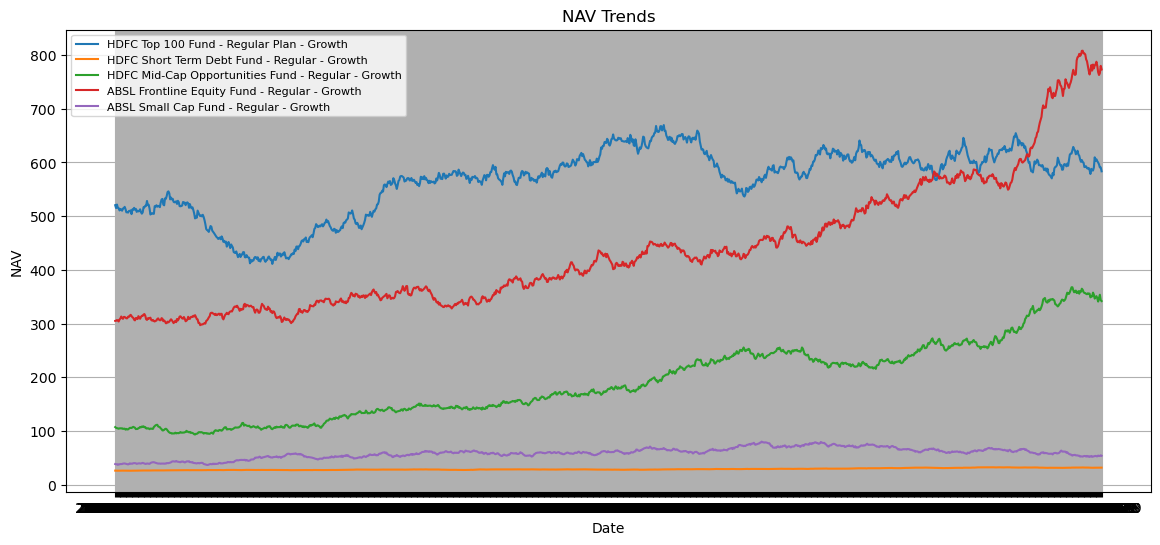

In [15]:
fund_map = funds.set_index("amfi_code")["scheme_name"].to_dict()

plt.figure(figsize=(14,6))

for code in sample_funds:
    temp = nav[nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=fund_map.get(code, str(code))
    )

plt.title("NAV Trends")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend(fontsize=8)
plt.grid(True)

plt.savefig("../charts/nav_trends.png", bbox_inches="tight")

plt.show()

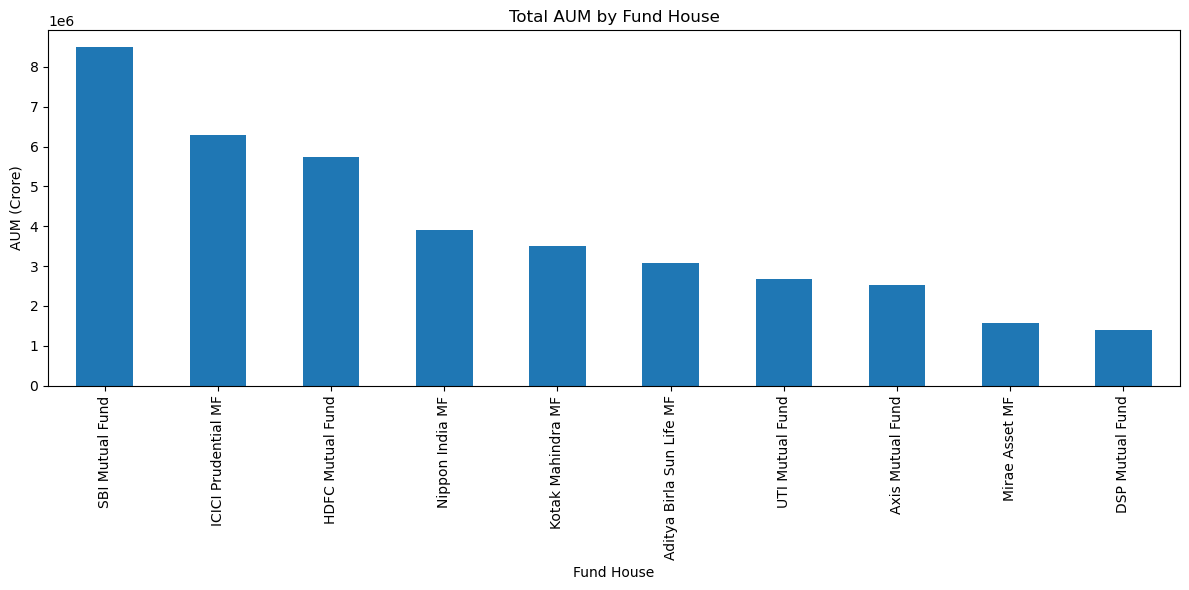

In [17]:
aum_summary = (
    aum.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

aum_summary.plot(kind="bar")

plt.title("Total AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.tight_layout()

plt.savefig("../charts/aum_growth.png", bbox_inches="tight")

plt.show()

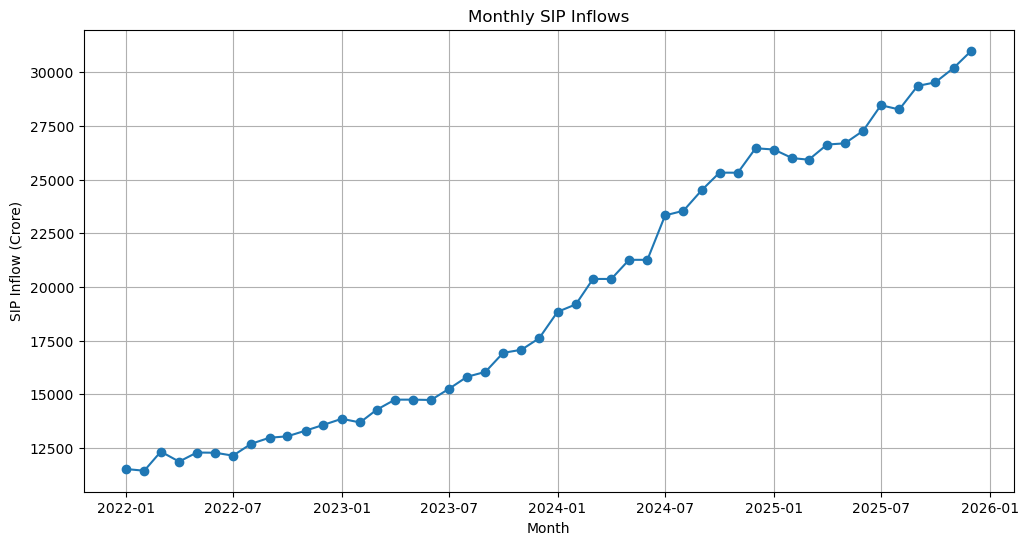

In [18]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.grid(True)

plt.savefig("../charts/sip_inflows.png", bbox_inches="tight")

plt.show()

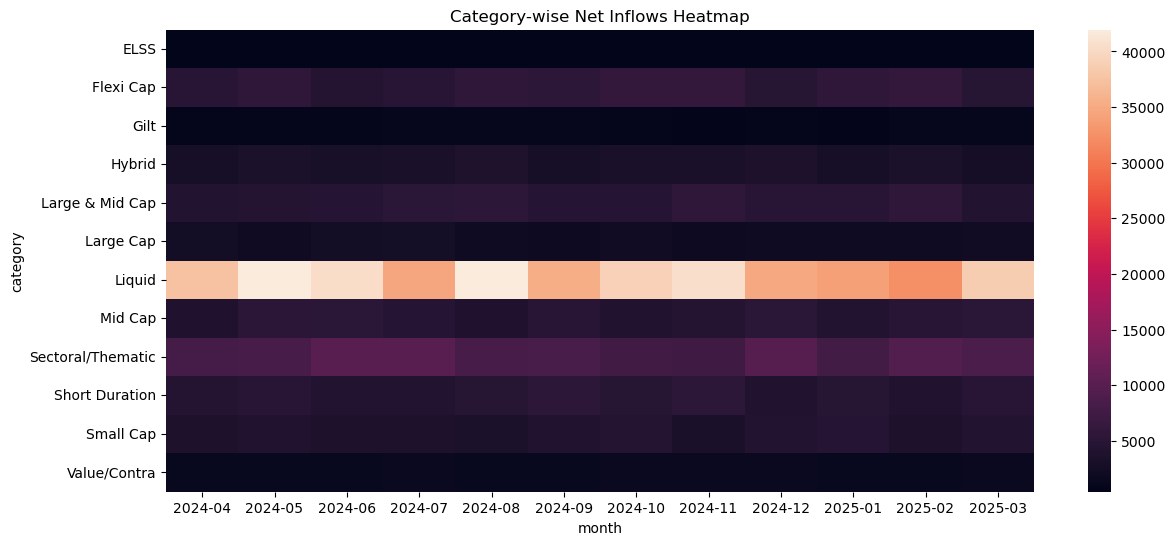

In [19]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")

plt.savefig("../charts/category_heatmap.png", bbox_inches="tight")

plt.show()

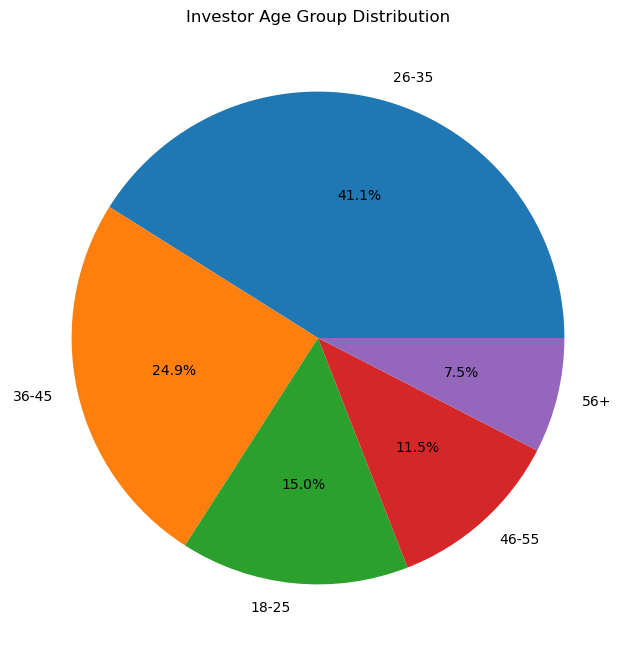

In [20]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Group Distribution")

plt.savefig("../charts/demographics.png", bbox_inches="tight")

plt.show()

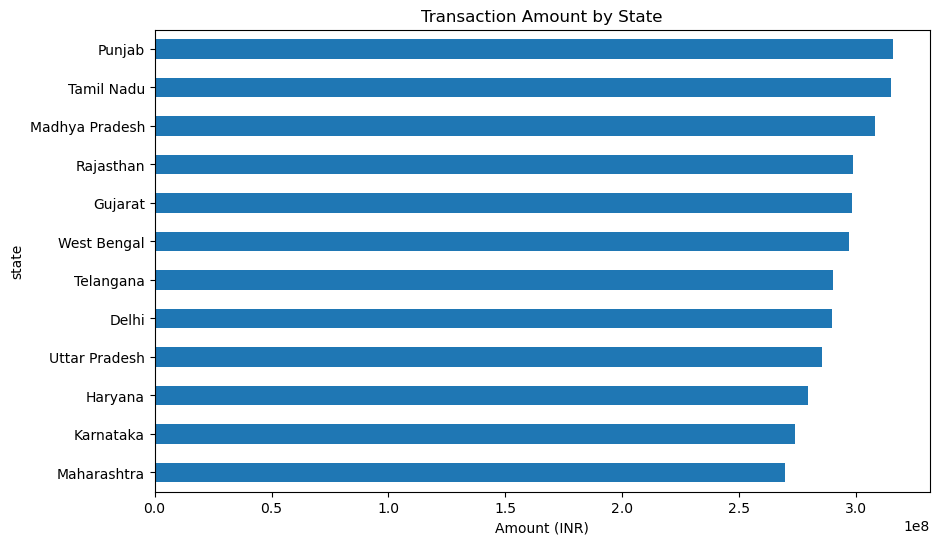

In [21]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))

state_data.plot(kind="barh")

plt.title("Transaction Amount by State")
plt.xlabel("Amount (INR)")

plt.savefig("../charts/state_distribution.png", bbox_inches="tight")

plt.show()

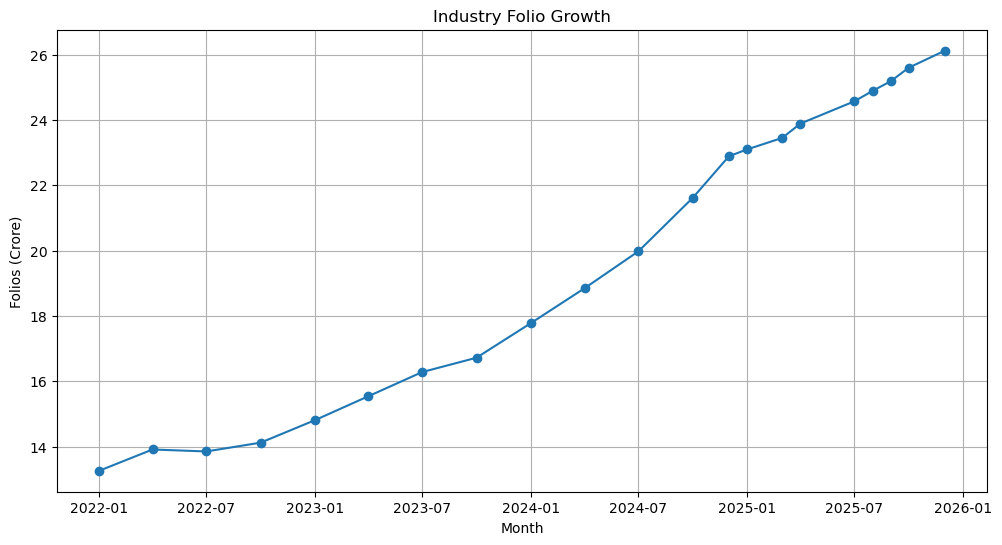

In [22]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.savefig("../charts/folio_growth.png", bbox_inches="tight")

plt.show()

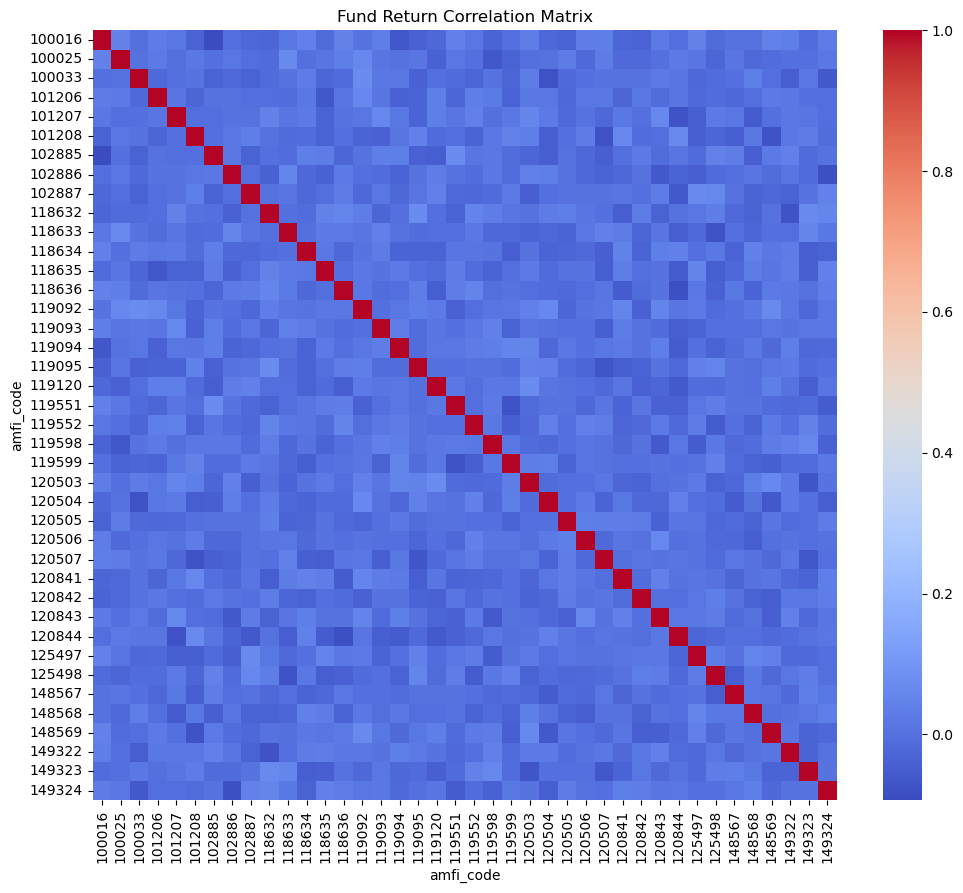

In [23]:
nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.savefig("../charts/correlation_matrix.png", bbox_inches="tight")

plt.show()

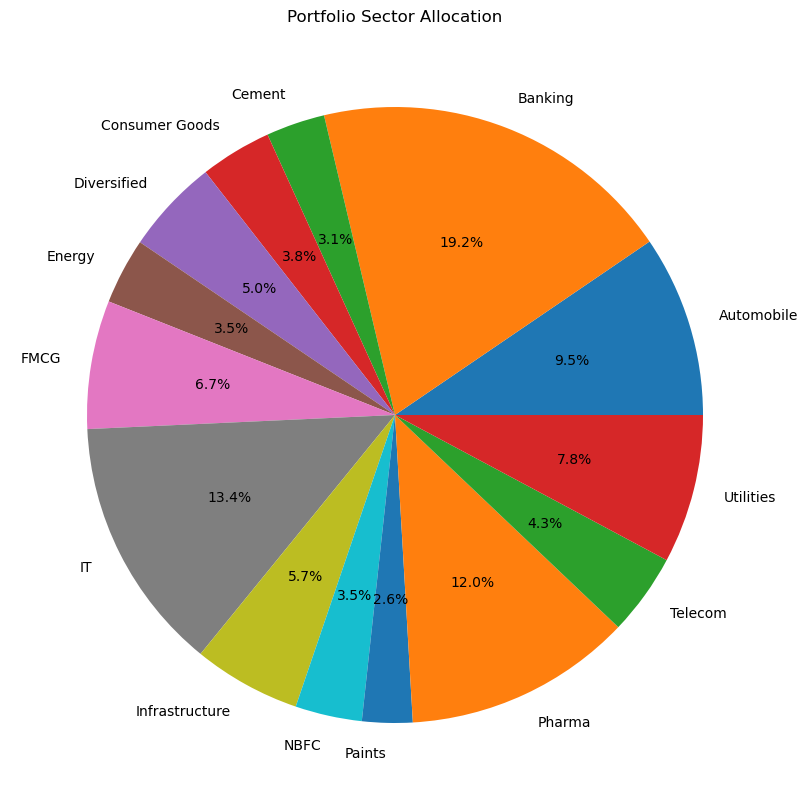

In [24]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(10,10))

sector.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Portfolio Sector Allocation")

plt.savefig("../charts/sector_allocation.png", bbox_inches="tight")

plt.show()